# Sphere MMD$^2$ Loss Landscape

We define:
- $Q$: uniform distribution on the unit sphere in $\mathbb{R}^d$
- $P_\theta$: uniform distribution on the sphere of radius $\theta$

This notebook computes the Gaussian-kernel population MMD$^2(P_\theta, Q)$ across a grid of $\theta$ values and plots the loss landscape.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from tqdm.auto import tqdm

def sample_unit_sphere(rng: np.random.Generator, n: int, dim: int) -> np.ndarray:
    """Sample points uniformly on the unit sphere S^{dim-1}."""
    x = rng.normal(size=(n, dim))
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    norms = np.clip(norms, 1e-12, None)
    return x / norms

@jax.jit
def gaussian_kernel_matrix_jax(x: jnp.ndarray, y: jnp.ndarray, sigma: float) -> jnp.ndarray:
    x_sq = jnp.sum(x * x, axis=1, keepdims=True)
    y_sq = jnp.sum(y * y, axis=1, keepdims=True).T
    sqdist = x_sq + y_sq - 2.0 * (x @ y.T)
    sqdist = jnp.maximum(sqdist, 0.0)
    return jnp.exp(-sqdist / (2.0 * sigma * sigma))

@jax.jit
def mmd2_biased_jax(x: jnp.ndarray, y: jnp.ndarray, sigma: float) -> jnp.ndarray:
    """Biased empirical MMD^2 with Gaussian kernel."""
    k_xx = gaussian_kernel_matrix_jax(x, x, sigma).mean()
    k_yy = gaussian_kernel_matrix_jax(y, y, sigma).mean()
    k_xy = gaussian_kernel_matrix_jax(x, y, sigma).mean()
    return k_xx + k_yy - 2.0 * k_xy

@jax.jit
def mmd2_over_theta_jax(theta_grid: jnp.ndarray, u: jnp.ndarray, y: jnp.ndarray, sigma: float) -> jnp.ndarray:
    # Vectorize over theta so we avoid Python loops in the hot path.
    def single_theta(theta):
        x = theta * u
        return mmd2_biased_jax(x, y, sigma)
    return jax.vmap(single_theta)(theta_grid)

def estimate_landscape(theta_grid, n_samples=1500, dim=3, sigma=0.5, repeats=10, seed=0):
    rng = np.random.default_rng(seed)
    losses = np.zeros_like(theta_grid, dtype=float)
    theta_grid_jax = jnp.asarray(theta_grid)

    # Reuse directions per repeat to reduce Monte Carlo variance across theta.
    for _ in tqdm(range(repeats), desc="Estimating landscape", leave=False):
        u = sample_unit_sphere(rng, n_samples, dim)
        v = sample_unit_sphere(rng, n_samples, dim)
        y = v  # Q is the unit sphere
        u_jax = jnp.asarray(u)
        y_jax = jnp.asarray(y)
        losses += np.asarray(mmd2_over_theta_jax(theta_grid_jax, u_jax, y_jax, sigma))

    return losses / repeats

In [12]:
plt.rcParams['axes.grid'] = True
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.labelsize'] = 18
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath, amsfonts, mathrsfs, amssymb}')


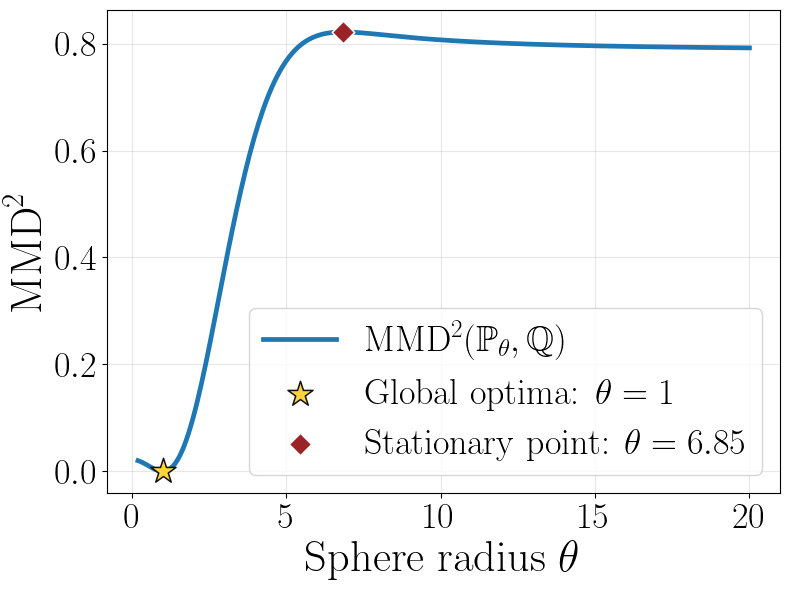

True theta: 1.000000, MMD^2 = 0.00000000
Other stationary theta: 6.852362, MMD^2 = 0.82172486


In [14]:
from scipy.optimize import brentq

# Experiment settings
dim = 3
sigma = 2.0  # Larger kernel lengthscale highlights the non-theta=1 stationary structure.

def sphere_kernel_expectation(radius_a, radius_b, sigma):
    z = radius_a * radius_b / sigma**2
    if np.isclose(z, 0.0):
        return np.exp(-(radius_a**2 + radius_b**2) / (2.0 * sigma**2))
    return np.exp(-(radius_a**2 + radius_b**2) / (2.0 * sigma**2)) * np.sinh(z) / z

def population_mmd2_sphere(theta, sigma):
    pp = sphere_kernel_expectation(theta, theta, sigma)
    qq = sphere_kernel_expectation(1.0, 1.0, sigma)
    pq = sphere_kernel_expectation(theta, 1.0, sigma)
    return pp + qq - 2.0 * pq

def finite_difference_derivative(func, x, eps=1e-5):
    step = eps * max(1.0, abs(x))
    return (func(x + step) - func(x - step)) / (2.0 * step)

theta_grid = np.linspace(0.2, 20.0, 280)
losses = np.array([population_mmd2_sphere(theta, sigma) for theta in theta_grid])

true_theta = 1.0
objective = lambda theta: population_mmd2_sphere(theta, sigma)
objective_derivative = lambda theta: finite_difference_derivative(objective, theta)
other_stationary_theta = brentq(objective_derivative, 1.1, theta_grid[-1])
true_loss = objective(true_theta)
other_stationary_loss = objective(other_stationary_theta)

figure_size = (8, 6)
axis_label_fontsize = 32
tick_label_fontsize = 26
legend_fontsize = 26

fig, ax = plt.subplots(figsize=figure_size, dpi=100)
ax.plot(theta_grid, losses, color="#1f77b4", lw=3.4, label=r"MMD$^2(\mathbb{P}_\theta, \mathbb{Q})$")
ax.scatter(
    [true_theta],
    [true_loss],
    marker="*",
    color="#FFD43B",
    edgecolors="#111111",
    linewidths=1.1,
    zorder=8,
    s=360,
    label=r"Global optima: $\theta = 1$",
)
ax.scatter(
    [other_stationary_theta],
    [other_stationary_loss],
    marker="D",
    color="#9B2226",
    edgecolors="white",
    linewidths=1.1,
    zorder=8,
    s=130,
    label=r"Stationary point: $\theta=6.85$",
)
ax.set_xlabel(r"Sphere radius $\theta$", fontsize=axis_label_fontsize)
ax.set_ylabel(r"$\mathrm{MMD}^2$", fontsize=axis_label_fontsize)
ax.tick_params(axis="both", labelsize=tick_label_fontsize)
ax.legend(loc="best", fontsize=legend_fontsize, frameon=True)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./figures/sphere_mmd_loss_landscape.pdf", bbox_inches="tight")
plt.show()

print(f"True theta: {true_theta:.6f}, MMD^2 = {true_loss:.8f}")
print(f"Other stationary theta: {other_stationary_theta:.6f}, MMD^2 = {other_stationary_loss:.8f}")